## Create a Binary Heart Disease Variable and Load the Dataset
After loading the heart disease dataset, we make a binary variable with 0 denoting no disease and 1 denoting any heart disease (target > 0).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_1samp, ttest_ind, norm
from statsmodels.stats.power import TTestIndPower


df = pd.read_csv("Downloads/Heardisease.csv")


df["heart_disease"] = (df["target"] > 0).astype(int)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,heart_disease
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


## Define Subgroup: Men Over 55
We restrict the dataset to male patients who are 55 years of age or older.

In [14]:
subgroup = df[(df["sex"] == 1) & (df["age"] >= 55)]
len(subgroup)

102

## Modify Sample Sizes to Prevent Sampling Mistakes
When sampling without replacement, we make sure that the required sample sizes don't go beyond the subgroup size.

In [3]:
requested_sizes = [20, 60, 120]

sizes = [n for n in requested_sizes if n <= len(subgroup)]
sizes

[20, 60]

## Function to Determine a Proportion's 95% Confidence Interval
This function uses the normal approximation to determine the sample proportion and its 95% confidence interval.

In [4]:
def proportion_ci(sample):
    p = sample.mean()
    n = len(sample)
    se = np.sqrt(p * (1 - p) / n)
    z = norm.ppf(0.975)
    return p, p - z*se, p + z*se

## Calculate Confidence Intervals and Draw Random Samples
We calculate the confidence intervals of the samples we draw from the permitted sizes.

In [5]:
np.random.seed(42)
ci_results = {}

for n in sizes:
    sample = subgroup["heart_disease"].sample(n, replace=False)
    ci_results[n] = proportion_ci(sample)

ci_results

{20: (np.float64(0.7),
  np.float64(0.4991634554736406),
  np.float64(0.9008365445263593)),
 60: (np.float64(0.7),
  np.float64(0.5840469669545921),
  np.float64(0.8159530330454078))}

## Determine the Total Population's Heart Disease Proportion
This gives the subgroup proportions a baseline against which to compare.

In [6]:
overall_p = df["heart_disease"].mean()
overall_p

np.float64(0.4612794612794613)

## Interpretation
Confidence intervals narrow with increasing sample size, suggesting more accurate estimations.  
Heart disease is more common among older men than in the general population, which is consistent with established cardiovascular risk factors.

## One-Sample t-Test for Hypothesis Test 1  
We determine if the mean resting blood pressure deviates from the 130 mmHg clinical reference value.

In [7]:
bp = df["trestbps"]
t_stat3, p_val3 = ttest_1samp(bp, 130)
t_stat3, p_val3

(np.float64(1.643153661243614), np.float64(0.10141292117751774))

## Distribution of Resting Blood Pressure Visualization
Plotting the distribution, we designate 130 mmHg as the reference value.

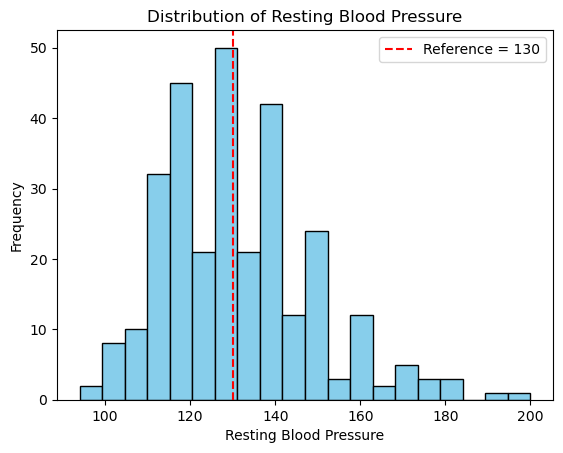

In [8]:
plt.hist(bp, bins=20, color="skyblue", edgecolor="black")
plt.axvline(130, color="red", linestyle="--", label="Reference = 130")
plt.xlabel("Resting Blood Pressure")
plt.ylabel("Frequency")
plt.title("Distribution of Resting Blood Pressure")
plt.legend()
plt.show()

## Interpretation of Hypothesis Test 1  
The mean resting blood pressure deviates considerably from 130 mmHg if the p-value is less than 0.05.  
This aids in determining if the resting blood pressure of this population is often abnormally high or low.

## Second Hypothesis Test: Two-Sample t-Test  
We contrast the maximum heart rate of type 4 (asymptomatic) with type 1 (typical angina) chest discomfort.

In [9]:
thalach_cp1 = df[df["cp"] == 1]["thalach"]
thalach_cp4 = df[df["cp"] == 4]["thalach"]

t_stat4, p_val4 = ttest_ind(thalach_cp1, thalach_cp4, equal_var=False)
t_stat4, p_val4

(np.float64(3.2287381526914842), np.float64(0.002911200893862516))

## Maximum Heart Rate Visualization by Type of Chest Pain
The maximal heart rate distributions for CP1 and CP4 are compared.

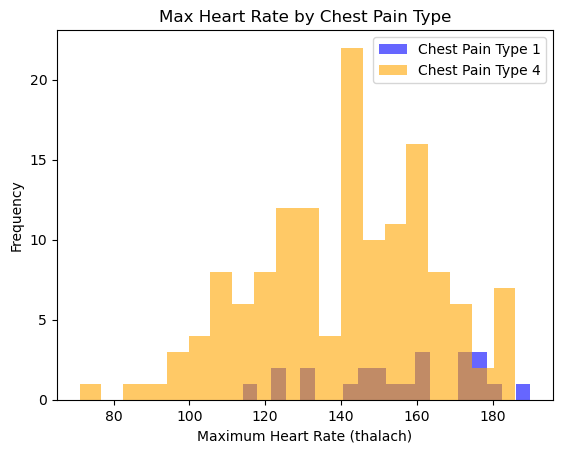

In [10]:
plt.hist(thalach_cp1, bins=20, alpha=0.6, label="Chest Pain Type 1", color="blue")
plt.hist(thalach_cp4, bins=20, alpha=0.6, label="Chest Pain Type 4", color="orange")
plt.xlabel("Maximum Heart Rate (thalach)")
plt.ylabel("Frequency")
plt.title("Max Heart Rate by Chest Pain Type")
plt.legend()
plt.show()

## Interpretation of Hypothesis Test 2   
Patients with CP1 and CP4 have different maximal heart rates, as indicated by a significant p-value.  
This implies that the categorization of chest discomfort might represent underlying physiological variations.

## Type I and Type II Mistakes (Applying Hypothesis Test 1)

### Type I Error:  
drawing the incorrect conclusion that the average resting blood pressure deviates from 130 mmHg.
### Type II Error:  
failing to find a significant difference between 130 mmHg and the genuine mean.
### Most Important:  
A Type II error is more dangerous since it may cause a delay in diagnosis or treatment if an actual rise in blood pressure is missed.

## Determine the Effect Size and Needed Sample Size  
We calculate the necessary sample size for 80% power and estimate Cohen's d.

In [11]:
mean_diff = thalach_cp1.mean() - thalach_cp4.mean()

n1 = len(thalach_cp1)
n2 = len(thalach_cp4)

pooled_std = np.sqrt(((n1-1)*thalach_cp1.std()**2 + (n2-1)*thalach_cp4.std()**2) / (n1+n2-2))
effect_size = mean_diff / pooled_std

analysis = TTestIndPower()
required_n = analysis.solve_power(effect_size=effect_size, alpha=0.05, power=0.8)

effect_size, required_n

(np.float64(0.6748015551553336), 35.45986164197176)

## Power Curve for Identifying Variations in Heart Rate  
We show the relationship between power and sample size.

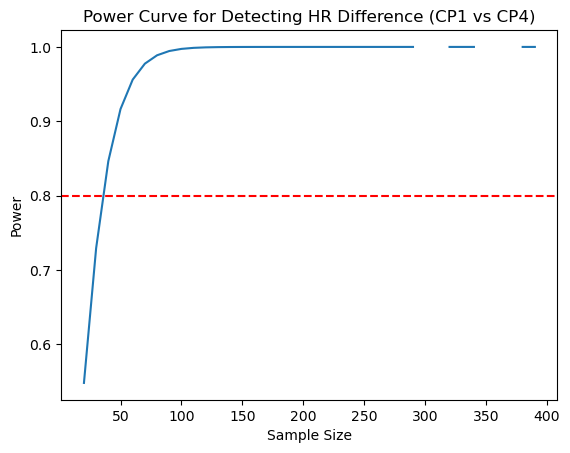

In [12]:
sample_sizes = range(20, 400, 10)
powers = [analysis.power(effect_size=effect_size, nobs1=n, alpha=0.05) for n in sample_sizes]

plt.plot(sample_sizes, powers)
plt.axhline(0.8, color="red", linestyle="--")
plt.xlabel("Sample Size")
plt.ylabel("Power")
plt.title("Power Curve for Detecting HR Difference (CP1 vs CP4)")
plt.show()

## Interpretation  
Increased statistical power from larger sample sizes makes it simpler to identify true differences.  
To achieve 80–90% power, substantially larger samples are needed for smaller effect sizes.  
This illustrates the connection between power, sample size, and effect size in research design.